# Tugas 3 - Pengolahan Data Deret Waktu (Time Series)
## Fokus Polutan: CO (Carbon Monoxide)

Langkah-langkah yang akan dilakukan:
1. Menangani missing values dengan imputasi.
2. Identifikasi outlier.
3. Perbaikan outlier.
4. Ekstraksi fitur menggunakan TSFEL (sebanyak 365 hari) dengan format kolom yang diminta.
5. Mencari kemiripan.

In [2]:
!pip install seaborn tsfel openpyxl

  Using cached tsfel-0.2.0-py3-none-any.whl.metadata (9.4 kB)
  Using cached pywavelets-1.10.0-cp314-cp314-win_amd64.whl.metadata (7.6 kB)
  Using cached statsmodels-0.15.0-cp314-cp314-win_amd64.whl.metadata (9.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached patsy-1.0.3-py2.py3-none-any.whl.metadata (3.7 kB)
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached interface_meta-2.0.1-py3-none-any.whl.metadata (6.4 kB)
Using cached tsfel-0.2.0-py3-none-any.whl (63 kB)
Using cached pywavelets-1.10.0-cp314-cp314-win_amd64.whl (4.3 MB)
   ---------------------------------------- 0.0/8.4 MB ? eta -:--:--
   ------ --------------------------------- 1.3/8.4 MB 6.1 MB/s eta 0:00:02
   ----------------- ---------------------- 3.7/8.4 MB 5.1 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.4 MB 4.6 MB/s eta 0:00:01
   -------------------------------------- - 8.1/8.4 MB 4.3 MB/s eta 0:00:01
   -------------------

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Path relatif dari src/1-project ke folder data
file_path = os.path.join('..', '..', 'data', 'data_kualitas_udara_telukdalam_restructured.xlsx')

# Load data (mulai dari baris ke-4 sebagai header)
df = pd.read_excel(file_path, header=3)
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])

# Kita hanya akan fokus pada kolom CO sesuai instruksi
print(df[['DATE_TIME', 'CO']].head())
print("\nJumlah data:", len(df))
print("Jumlah missing values CO:", df['CO'].isnull().sum())

   DATE_TIME  CO
0 2025-08-30 NaN
1 2025-08-31 NaN
2 2025-09-01 NaN
3 2025-09-02 NaN
4 2025-09-03 NaN

Jumlah data: 366
Jumlah missing values CO: 265


### 1. Menangani Missing Values (Imputasi)
Karena ini data time-series, kita akan menggunakan teknik interpolasi linear, lalu menggunakan ffill/bfill untuk data di ujung yang tidak terinterpolasi.

In [4]:
# Imputasi menggunakan linear interpolation
df['CO_imputed'] = df['CO'].interpolate(method='linear')

# Jika ada NaN di awal/akhir, kita gunakan bfill dan ffill
df['CO_imputed'] = df['CO_imputed'].bfill().ffill()

# Cek hasil imputasi
print("Missing values setelah imputasi:", df['CO_imputed'].isnull().sum())

Missing values setelah imputasi: 0


### 2. Identifikasi Outlier
Menggunakan metode Interquartile Range (IQR).

In [5]:
Q1 = df['CO_imputed'].quantile(0.25)
Q3 = df['CO_imputed'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['CO_imputed'] < lower_bound) | (df['CO_imputed'] > upper_bound)]
print(f"Batas Bawah: {lower_bound}")
print(f"Batas Atas: {upper_bound}")
print(f"Jumlah outlier ditemukan: {len(outliers)}")

Batas Bawah: 0.018023815408179718
Batas Atas: 0.04073514598139532
Jumlah outlier ditemukan: 0


### 3. Perbaiki Outlier
Memperbaiki outlier menggunakan teknik *capping* (Winsorizing), yaitu mengganti nilai yang lebih dari batas atas dengan batas atas, dan nilai yang kurang dari batas bawah dengan batas bawah.

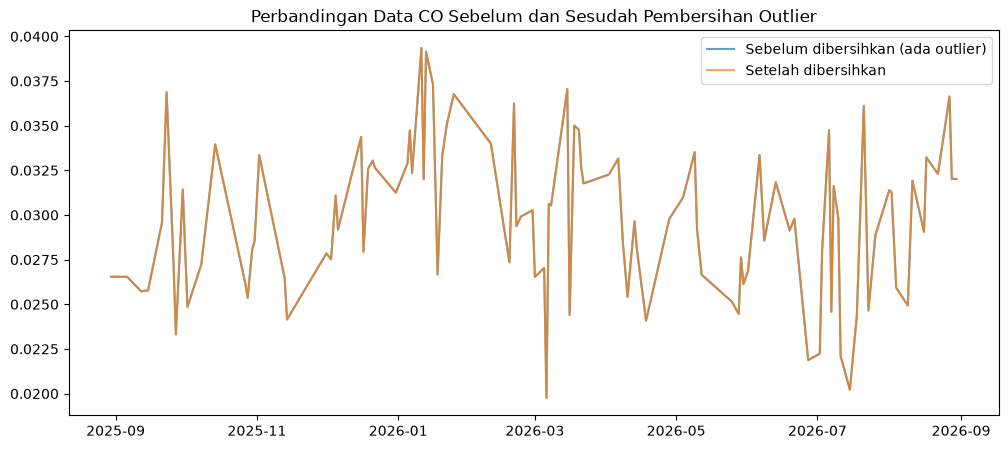

In [6]:
df['CO_cleaned'] = np.where(df['CO_imputed'] > upper_bound, upper_bound,
                   np.where(df['CO_imputed'] < lower_bound, lower_bound, df['CO_imputed']))

# Plot perbandingan
plt.figure(figsize=(12, 5))
plt.plot(df['DATE_TIME'], df['CO_imputed'], label='Sebelum dibersihkan (ada outlier)', alpha=0.7)
plt.plot(df['DATE_TIME'], df['CO_cleaned'], label='Setelah dibersihkan', alpha=0.7)
plt.legend()
plt.title("Perbandingan Data CO Sebelum dan Sesudah Pembersihan Outlier")
plt.show()

### 4. Ekstraksi Fitur dengan TSFEL
Mengekstrak fitur menggunakan `tsfel` dari 365 data observasi CO yang sudah dibersihkan, dan mengubah nama kolomnya ke format `[nama_fitur] (ke-X/fX)`.

In [8]:
import pandas as pd
import tsfel

# Ambil data series sebanyak 365 hari
co_data = df['CO_cleaned'].values[:365]

# Mengambil konfigurasi fitur TSFEL
cfg = tsfel.get_features_by_domain()

# Ekstraksi fitur per komponen untuk mencegah bentrokan nama kolom duplikat di TSFEL
print("Memulai ekstraksi fitur...")
feature_dfs = []
for domain in cfg:
    for feat_name, feat_cfg in cfg[domain].items():
        try:
            sub_cfg = {domain: {feat_name: feat_cfg}}
            df_feat = tsfel.time_series_features_extractor(
                sub_cfg, co_data, fs=1, verbose=0
            )
            feature_dfs.append(df_feat)
        except Exception:
            continue

# Gabungkan seluruh fitur yang berhasil diekstrak
features = pd.concat(feature_dfs, axis=1)

# Hapus nama kolom duplikat (jika ada)
features = features.loc[:, ~features.columns.duplicated()]

# Mengubah nama kolom ke format [nama_fitur] (ke-1/f1), dst
new_columns = {}
for i, col in enumerate(features.columns):
    new_columns[col] = f"{col} (ke-{i+1}/f{i+1})"

features.rename(columns=new_columns, inplace=True)

# Tampilkan hasil
print(f"Total fitur berhasil diekstrak: {features.shape[1]}")
display(features.head())

Memulai ekstraksi fitur...
Total fitur berhasil diekstrak: 120


,0_Spectrogram mean coefficient_0.02Hz (ke-1/f1),0_Spectrogram mean coefficient_0.03Hz (ke-2/f2),0_Spectrogram mean coefficient_0.05Hz (ke-3/f3),0_Spectrogram mean coefficient_0.06Hz (ke-4/f4),0_Spectrogram mean coefficient_0.08Hz (ke-5/f5),0_Spectrogram mean coefficient_0.0Hz (ke-6/f6),0_Spectrogram mean coefficient_0.11Hz (ke-7/f7),0_Spectrogram mean coefficient_0.13Hz (ke-8/f8),0_Spectrogram mean coefficient_0.15Hz (ke-9/f9),0_Spectrogram mean coefficient_0.16Hz (ke-10/f10),...,0_Mean diff (ke-111/f111),0_Median absolute diff (ke-112/f112),0_Median diff (ke-113/f113),0_Negative turning points (ke-114/f114),0_Neighbourhood peaks (ke-115/f115),0_Positive turning points (ke-116/f116),0_Signal distance (ke-117/f117),0_Slope (ke-118/f118),0_Sum absolute diff (ke-119/f119),0_Zero crossing rate (ke-120/f120)
0,0.000142,0.00008,0.000106,0.000049,0.000038,0.000003,0.000018,0.000013,0.00001,0.000008,...,0.000015,0.000569,0.000046,32,12,32,364.000756,-0.000001,0.409213,0


In [10]:
# 1. Menampilkan seluruh 120 nama kolom fitur secara berurutan
for col in features.columns:
    print(col)

# 2. Atau hilangkan batasan kolom pada tampilan Pandas
pd.set_option('display.max_columns', None)
display(features)


0_Spectrogram mean coefficient_0.02Hz (ke-1/f1)
0_Spectrogram mean coefficient_0.03Hz (ke-2/f2)
0_Spectrogram mean coefficient_0.05Hz (ke-3/f3)
0_Spectrogram mean coefficient_0.06Hz (ke-4/f4)
0_Spectrogram mean coefficient_0.08Hz (ke-5/f5)
0_Spectrogram mean coefficient_0.0Hz (ke-6/f6)
0_Spectrogram mean coefficient_0.11Hz (ke-7/f7)
0_Spectrogram mean coefficient_0.13Hz (ke-8/f8)
0_Spectrogram mean coefficient_0.15Hz (ke-9/f9)
0_Spectrogram mean coefficient_0.16Hz (ke-10/f10)
0_Spectrogram mean coefficient_0.18Hz (ke-11/f11)
0_Spectrogram mean coefficient_0.19Hz (ke-12/f12)
0_Spectrogram mean coefficient_0.1Hz (ke-13/f13)
0_Spectrogram mean coefficient_0.21Hz (ke-14/f14)
0_Spectrogram mean coefficient_0.23Hz (ke-15/f15)
0_Spectrogram mean coefficient_0.24Hz (ke-16/f16)
0_Spectrogram mean coefficient_0.26Hz (ke-17/f17)
0_Spectrogram mean coefficient_0.27Hz (ke-18/f18)
0_Spectrogram mean coefficient_0.29Hz (ke-19/f19)
0_Spectrogram mean coefficient_0.31Hz (ke-20/f20)
0_Spectrogram mean c

,0_Spectrogram mean coefficient_0.02Hz (ke-1/f1),0_Spectrogram mean coefficient_0.03Hz (ke-2/f2),0_Spectrogram mean coefficient_0.05Hz (ke-3/f3),0_Spectrogram mean coefficient_0.06Hz (ke-4/f4),0_Spectrogram mean coefficient_0.08Hz (ke-5/f5),0_Spectrogram mean coefficient_0.0Hz (ke-6/f6),0_Spectrogram mean coefficient_0.11Hz (ke-7/f7),0_Spectrogram mean coefficient_0.13Hz (ke-8/f8),0_Spectrogram mean coefficient_0.15Hz (ke-9/f9),0_Spectrogram mean coefficient_0.16Hz (ke-10/f10),0_Spectrogram mean coefficient_0.18Hz (ke-11/f11),0_Spectrogram mean coefficient_0.19Hz (ke-12/f12),0_Spectrogram mean coefficient_0.1Hz (ke-13/f13),0_Spectrogram mean coefficient_0.21Hz (ke-14/f14),0_Spectrogram mean coefficient_0.23Hz (ke-15/f15),0_Spectrogram mean coefficient_0.24Hz (ke-16/f16),0_Spectrogram mean coefficient_0.26Hz (ke-17/f17),0_Spectrogram mean coefficient_0.27Hz (ke-18/f18),0_Spectrogram mean coefficient_0.29Hz (ke-19/f19),0_Spectrogram mean coefficient_0.31Hz (ke-20/f20),0_Spectrogram mean coefficient_0.32Hz (ke-21/f21),0_Spectrogram mean coefficient_0.34Hz (ke-22/f22),0_Spectrogram mean coefficient_0.35Hz (ke-23/f23),0_Spectrogram mean coefficient_0.37Hz (ke-24/f24),0_Spectrogram mean coefficient_0.39Hz (ke-25/f25),0_Spectrogram mean coefficient_0.42Hz (ke-26/f26),0_Spectrogram mean coefficient_0.44Hz (ke-27/f27),0_Spectrogram mean coefficient_0.45Hz (ke-28/f28),0_Spectrogram mean coefficient_0.47Hz (ke-29/f29),0_Spectrogram mean coefficient_0.48Hz (ke-30/f30),0_Spectrogram mean coefficient_0.4Hz (ke-31/f31),0_Spectrogram mean coefficient_0.5Hz (ke-32/f32),0_Fundamental frequency (ke-33/f33),0_Human range energy (ke-34/f34),0_LPCC_0 (ke-35/f35),0_LPCC_1 (ke-36/f36),0_LPCC_10 (ke-37/f37),0_LPCC_11 (ke-38/f38),0_LPCC_2 (ke-39/f39),0_LPCC_3 (ke-40/f40),0_LPCC_4 (ke-41/f41),0_LPCC_5 (ke-42/f42),0_LPCC_6 (ke-43/f43),0_LPCC_7 (ke-44/f44),0_LPCC_8 (ke-45/f45),0_LPCC_9 (ke-46/f46),0_MFCC_0 (ke-47/f47),0_MFCC_1 (ke-48/f48),0_MFCC_10 (ke-49/f49),0_MFCC_11 (ke-50/f50),0_MFCC_2 (ke-51/f51),0_MFCC_3 (ke-52/f52),0_MFCC_4 (ke-53/f53),0_MFCC_5 (ke-54/f54),0_MFCC_6 (ke-55/f55),0_MFCC_7 (ke-56/f56),0_MFCC_8 (ke-57/f57),0_MFCC_9 (ke-58/f58),0_Max power spectrum (ke-59/f59),0_Maximum frequency (ke-60/f60),0_Median frequency (ke-61/f61),0_Power bandwidth (ke-62/f62),0_Spectral centroid (ke-63/f63),0_Spectral decrease (ke-64/f64),0_Spectral distance (ke-65/f65),0_Spectral entropy (ke-66/f66),0_Spectral kurtosis (ke-67/f67),0_Spectral positive turning points (ke-68/f68),0_Spectral roll-off (ke-69/f69),0_Spectral roll-on (ke-70/f70),0_Spectral skewness (ke-71/f71),0_Spectral slope (ke-72/f72),0_Spectral spread (ke-73/f73),0_Spectral variation (ke-74/f74),0_Wavelet entropy (ke-75/f75),0_Absolute energy (ke-76/f76),0_Average power (ke-77/f77),0_ECDF_0 (ke-78/f78),0_ECDF_1 (ke-79/f79),0_ECDF_2 (ke-80/f80),0_ECDF_3 (ke-81/f81),0_ECDF_4 (ke-82/f82),0_ECDF_5 (ke-83/f83),0_ECDF_6 (ke-84/f84),0_ECDF_7 (ke-85/f85),0_ECDF_8 (ke-86/f86),0_ECDF_9 (ke-87/f87),0_ECDF Percentile_0 (ke-88/f88),0_ECDF Percentile_1 (ke-89/f89),0_ECDF Percentile Count_0 (ke-90/f90),0_ECDF Percentile Count_1 (ke-91/f91),0_Entropy (ke-92/f92),0_Histogram mode (ke-93/f93),0_Interquartile range (ke-94/f94),0_Kurtosis (ke-95/f95),0_Max (ke-96/f96),0_Mean (ke-97/f97),0_Mean absolute deviation (ke-98/f98),0_Median (ke-99/f99),0_Median absolute deviation (ke-100/f100),0_Min (ke-101/f101),0_Peak to peak distance (ke-102/f102),0_Root mean square (ke-103/f103),0_Skewness (ke-104/f104),0_Standard deviation (ke-105/f105),0_Variance (ke-106/f106),0_Area under the curve (ke-107/f107),0_Autocorrelation (ke-108/f108),0_Centroid (ke-109/f109),0_Mean absolute diff (ke-110/f110),0_Mean diff (ke-111/f111),0_Median absolute diff (ke-112/f112),0_Median diff (ke-113/f113),0_Negative turning points (ke-114/f114),0_Neighbourhood peaks (ke-115/f115),0_Positive turning points (ke-116/f116),0_Signal distance (ke-117/f117),0_Slope (ke-118/f118),0_Sum absolute diff (ke-119/f119),0_Zero crossing rate (ke-120/f120)
0,0.00

In [11]:
import pandas as pd
import tsfel

# 1. Ambil data series CO sebanyak 365 hari
co_data = df["CO_cleaned"].values[:365]

# 2. Ambil konfigurasi fitur TSFEL
cfg = tsfel.get_features_by_domain()

# 3. Ekstraksi fitur per modul
feature_dfs = []
for domain in cfg:
    for feat_name, feat_cfg in cfg[domain].items():
        try:
            sub_cfg = {domain: {feat_name: feat_cfg}}
            df_feat = tsfel.time_series_features_extractor(
                sub_cfg, co_data, fs=1, verbose=0
            )
            feature_dfs.append(df_feat)
        except Exception:
            continue

# 4. Gabungkan seluruh fitur & hapus duplikat jika ada
features = pd.concat(feature_dfs, axis=1)
features = features.loc[:, ~features.columns.duplicated()]

# 5. Penamaan kolom dengan format: [nama_fitur] (ke-1/f1), dst
new_columns = {}
for i, col in enumerate(features.columns):
    new_columns[col] = f"{col} (ke-{i+1}/f{i+1})"
features.rename(columns=new_columns, inplace=True)

# 6. UBAH KE TABEL VERTIKAL (Transponasi agar tersusun ke bawah)
tabel_fitur = features.T.reset_index()
tabel_fitur.columns = ["Nama Fitur (ke-x/fx)", "Nilai Hasil Ekstraksi"]

# 7. Tampilkan seluruh fitur tanpa terpotong
pd.set_option("display.max_rows", None)
print(f"Total fitur yang diekstrak: {len(tabel_fitur)}")
display(tabel_fitur)

Total fitur yang diekstrak: 120


,Nama Fitur (ke-x/fx),Nilai Hasil Ekstraksi
0,0_Spectrogram mean coefficient_0.02Hz (ke-1/f1),1.420041e-04
1,0_Spectrogram mean coefficient_0.03Hz (ke-2/f2),7.997829e-05
2,0_Spectrogram mean coefficient_0.05Hz (ke-3/f3),1.063622e-04
3,0_Spectrogram mean coefficient_0.06Hz (ke-4/f4),4.861694e-05
4,0_Spectrogram mean coefficient_0.08Hz (ke-5/f5),3.819846e-05
5,0_Spectrogram mean coefficient_0.0Hz (ke-6/f6),3.341676e-06
6,0_Spectrogram mean coefficient_0.11Hz (ke-7/f7),1.771103e-05
7,0_Spectrogram mean coefficient_0.13Hz (ke-8/f8),1.282035e-05
8,0_Spectrogram mean coefficient_0.15Hz (ke-9/f9),9.647195e-06
9,0_Spectrogram mean coefficient_0.16Hz (ke-10/f10),8.245914e-06


### 5. Mencari Kemiripan
*Catatan: Karena kolom CO2 tidak tersedia di dalam dataset, kita akan menggunakan kolom CH4 (atau NO2) sebagai pembanding polutan untuk perhitungan kemiripan. Jika yang dimaksud adalah mencari kemiripan berdasarkan data lain, silahkan ganti variabel target.*
Di sini kita menggunakan perbandingan jarak Euclidean dan Cosine Similarity.

In [9]:
from scipy.spatial.distance import euclidean, cosine

# Siapkan data pembanding (misalnya CH4) dengan imputasi
df['CH4_imputed'] = df['CH4'].interpolate(method='linear').bfill().ffill()

# Hitung Euclidean Distance
jarak_euclidean = euclidean(df['CO_cleaned'], df['CH4_imputed'])

# Hitung Cosine Similarity (1 - Cosine Distance)
kemiripan_cosine = 1 - cosine(df['CO_cleaned'], df['CH4_imputed'])

print(f"Jarak Euclidean antara CO dan pembanding: {jarak_euclidean}")
print(f"Cosine Similarity antara CO dan pembanding: {kemiripan_cosine}")

Jarak Euclidean antara CO dan pembanding: 36211.301693160814
Cosine Similarity antara CO dan pembanding: 0.9921989052533169
